In [1]:
from liset_seizures import liset_seizures
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
parent=r"E:\neurospark_mat\KA MODEL TRANSITION SESSIONS"
sessions=os.listdir(parent) 

for i,s in enumerate(sessions):
    print(f"{i}: {s}")
idx = int(input("Select session index: "))
session = sessions[idx]
data_path=os.path.join(parent,session)

0: Calb01uLED_hippo_2022-12-21_13-10-56_1558um
1: Calb01uLED_hippo_2022-12-21_14-12-20_1558um
2: Calb01uLED_hippo_2022-12-21_17-39-06_1558um
3: Calb01uLED_hippo_2022-12-22_09-52-13_1558um
4: Calb01uLED_hippo_2023-01-09_11-28-01_1558um
5: Calb01uLED_hippo_2023-01-12_10-19-17_1558um
6: Calb01uLED_hippo_2023-01-13_09-56-47_1558um
7: KA MODEL SESSIONS.xlsx
8: Thy01uLED_hippo_2022-12-21_merged
9: Thy01uLED_hippo_2022-12-22_merged
10: Thy01uLED_hippo_2023-01-09_12-45-53_1558um
11: Thy01uLED_hippo_2023-01-17_09-36-28_1558um
12: Thy01uLED_hippo_2023-01-17_merged


In [8]:
liset=liset_seizures(data_path,shank=1,downsample=1000,normalize=False,start=0,verbose=True)

.mat file loaded with h5py
Data loaded from E:\neurospark_mat\KA MODEL TRANSITION SESSIONS\Calb01uLED_hippo_2023-01-12_10-19-17_1558um/lfp.dat
Data shape: (109906944, 8)
Data type: float64
Downsampling data from 30000 Hz to 1000 Hz... Done!
IISs times loaded: [ 175033  505095  515750 ... 3600198 3600225 3600450]
IISs SD loaded: 8.0
Number of IISs loaded: 2799
Seizure times loaded: [[ 525000  530000]
 [ 980000 1010000]
 [1475000 1510000]
 [1945000 2010000]
 [2250000 2330000]
 [2820000 2825000]
 [2950000 2960000]
 [3095000 3110000]
 [3255000 3270000]
 [3450000 3460000]
 [3550000 3600000]]
Seizure thresholds loaded: 10.0
Seizure durations loaded: 5.0
Number of seizures loaded: (11, 2)


In [9]:
liset.seizure_times

array([[ 525000,  530000],
       [ 980000, 1010000],
       [1475000, 1510000],
       [1945000, 2010000],
       [2250000, 2330000],
       [2820000, 2825000],
       [2950000, 2960000],
       [3095000, 3110000],
       [3255000, 3270000],
       [3450000, 3460000],
       [3550000, 3600000]])

In [10]:
liset.IISs_times


array([ 175033,  505095,  515750, ..., 3600198, 3600225, 3600450])

[ 981.141  981.845  981.894  982.568  982.84   983.062  983.109  983.674
  984.004  984.052  984.368  984.409  984.513  984.905  984.947  985.057
  985.346  985.485  985.601  985.612  985.624  985.777  986.123  986.134
  986.197  986.25   986.266  986.277  986.306  986.318  986.393  986.407
  986.418  986.584  986.597  986.607  986.65   986.719  986.758  986.776
  986.786  986.999  987.066  987.135  987.201  987.341  990.121  990.174
  990.29   990.346  990.793  990.974  991.31   991.791  992.226  992.539
  992.713  993.168  994.326  994.386  994.903  995.158  995.554  996.097
  996.428  996.832  997.189  997.481  997.65   997.677  998.058  998.096
  998.588  998.639  999.074  999.103  999.113  999.287  999.619  999.667
  999.702 1000.116 1000.138 1000.158 1000.196 1000.31  1000.428 1000.844
 1000.892 1001.214 1001.742 1001.762 1001.794 1002.198 1002.712 1003.054
 1003.421 1003.678 1003.71  1003.781 1004.135 1004.153 1004.506 1004.801
 1004.829 1005.313 1005.489 1005.836 1005.857 1005.

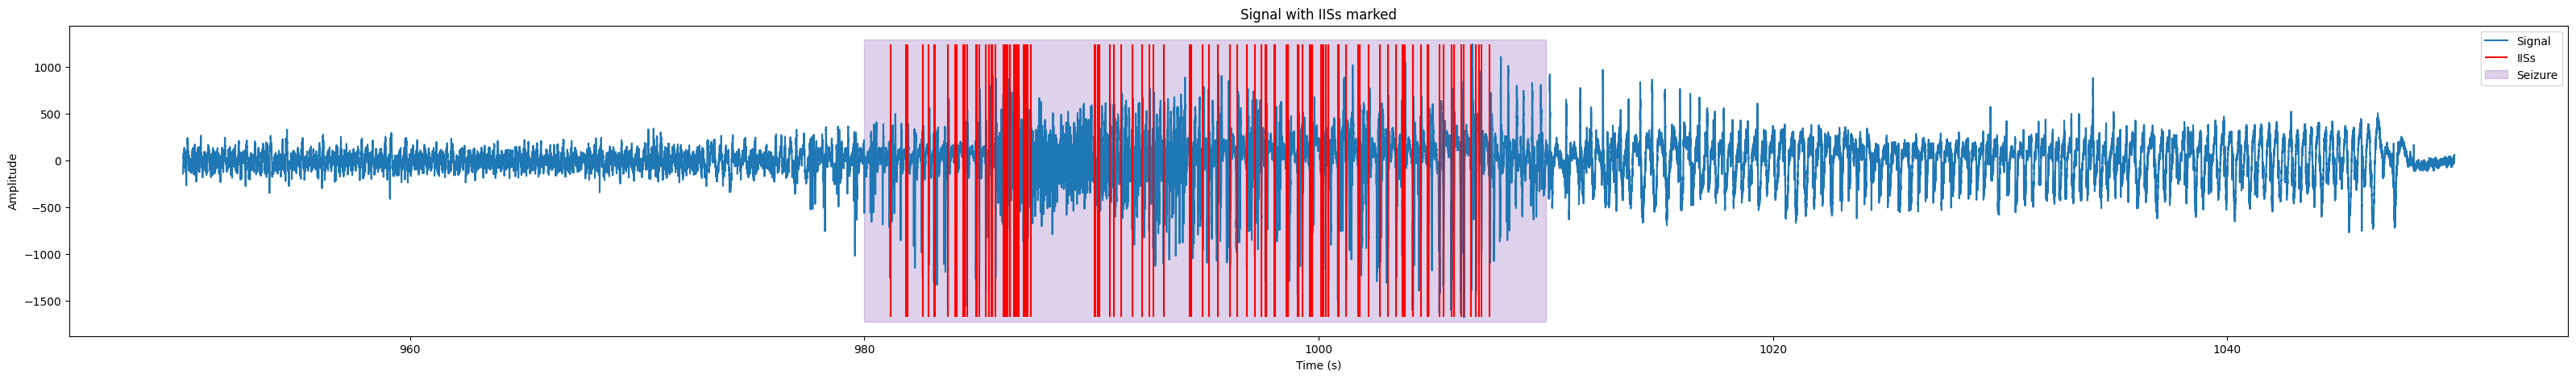

In [19]:
window = [950,1050]  # seconds
data = liset.data[window[0]*liset.fs : window[1]*liset.fs, :]
time = np.arange(data.shape[0]) / liset.fs + window[0]  # shift to window start
min_val, max_val = np.min(data), np.max(data)
plt.figure(figsize=(40, 5))
plt.plot(time, data[:, 0], label="Signal")

# Plot IISs inside window
if hasattr(liset, "IISs_times"):
    # Convert sample indices to seconds
    IIS_times_sec = liset.IISs_times / liset.fs

    # Keep only IISs that fall inside window
    mask = (IIS_times_sec >= window[0]) & (IIS_times_sec <= window[1])
    IIS_in_window = IIS_times_sec[mask]

    # Mark them on the plot
    # plt.scatter(IIS_in_window, 
    #             np.zeros_like(IIS_in_window),  # baseline marker
    #             color="red", marker="x", s=100, label="IISs")
    plt.vlines(IIS_in_window, ymin=min(data[:,0]), ymax=max(data[:,0]), color="red", label="IISs")
    print(IIS_in_window)

if hasattr(liset, "seizure_times"):
    # Convert sample indices to seconds
    seizure_times_sec = liset.seizure_times / liset.fs

    # Keep only seizures that fall inside window
    for start, end in seizure_times_sec:
                if end >= window[0] and start <= window[1]:
                    start = max(start, window[0])
                    end = min(end, window[1])
                    fill_SZ = plt.fill_between([start, end],
                                            min_val, max_val,
                                            color="tab:purple", alpha=0.3,
                                            label="Seizure")

    # Mark them on the plot
    # plt.vlines(seizures_in_window, ymin=min(data[:,0]), ymax=max(data[:,0]), color="green", label="Seizures")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Signal with IISs marked")
plt.show()


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Event samples [950000, 1050000]'}, xlabel='Time (s)', ylabel='Amplitude (mV)'>)

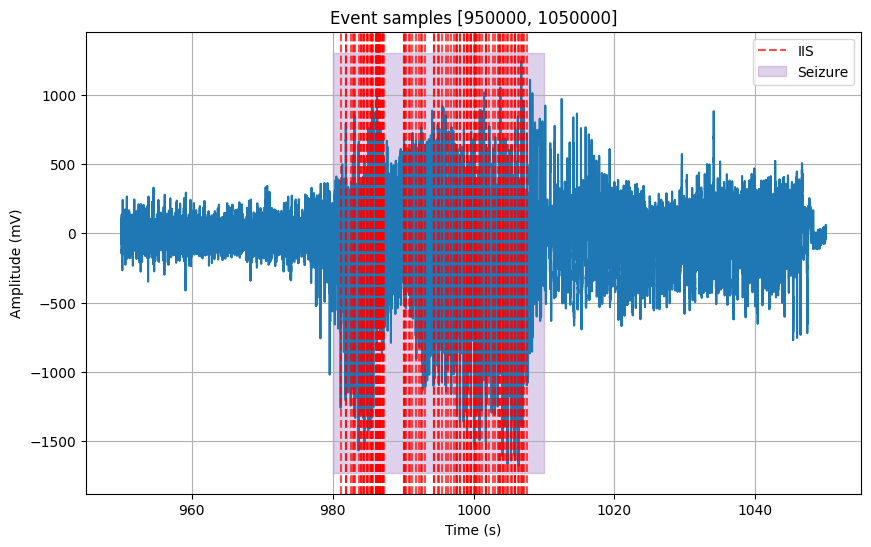

In [20]:
liset.plot_event_with_IISs_and_seizures(
        event=window,             # [start, end] in samples
        offset=1.5,
        extend=0,
        delimiter=False,
        show=True,
        filtered=[],
        title='',
        ch=[0,],  # channels to plot, None for all
        ylim=False,
        line_color=False,
        show_IISs=True,
        show_seizures=True,
    )